# WarpKriging with ordinal warping (Python)

The **ordinal** warp maps each level $\ell \in \{0, \ldots, L-1\}$ to a learned position
on $\mathbb{R}$, respecting the natural ordering. This is appropriate when one input is
discrete and ordered (e.g., resolution level, quality grade).

Here we discretize $x_1$ of the Branin function into 5 ordered levels while keeping $x_2$ continuous.

## 0. Installation

Set `REPO_ROOT`, then optionally create a venv and install build requirements
(skip the build cells if pylibkriging is already installed).

In [1]:
%%bash
REPO_ROOT=$(cd ../.. && pwd)
echo "REPO_ROOT=${REPO_ROOT}"

REPO_ROOT=/home/richet/Sync/Open/libKriging/alien/libKriging


In [2]:
%%bash
# Optional: skip if pylibkriging is already installed
set -e
REPO_ROOT=$(cd ../.. && pwd)
VENV_DIR=./venv

# Create venv if needed
if [ ! -d "${VENV_DIR}" ]; then
    python3 -m venv "${VENV_DIR}"
fi
source "${VENV_DIR}/bin/activate"

# Install build requirements
pip install -q \
    -r "${REPO_ROOT}/bindings/Python/pylibkriging/requirements.txt" \
    -r "${REPO_ROOT}/bindings/Python/pylibkriging/dev-requirements.txt"

pip install matplotlib

lib) (1.3.3)


 (0.12.1)


tlib) (4.62.1)


tlib) (1.5.0)


(1.26.4)


ib) (26.0)


2.1.1)


 (3.3.2)


plotlib) (2.9.0.post0)


>=2.7->matplotlib) (1.17.0)


In [3]:
%%bash
# Optional: compile libkriging from source if not already built
set -e
REPO_ROOT=$(cd ../.. && pwd)

    cd "${REPO_ROOT}"
    # Point repo-level venv to our local one so loadenv.sh picks it up
    if [ ! -e venv ]; then
        ln -s bindings/Python/venv venv
    fi
    source venv/bin/activate
    
if [ -d "${REPO_ROOT}/build/installed" ]; then
    echo "libkriging already built, skipping build step"
else
    # Force cmake to use the venv python
    EXTRA_CMAKE_OPTIONS="-DPYTHON_EXECUTABLE=$(which python3)" \
        ENABLE_PYTHON_BINDING=on BUILD_TEST=false \
        tools/linux-macos/build.sh
fi


libkriging already built, skipping build step


In [4]:
%%bash
REPO_ROOT=$(cd ../.. && pwd)
# Optional: skip if pylibkriging is already installed
pip install --no-build-isolation ${REPO_ROOT}/bindings/Python/pylibkriging/

Processing ./pylibkriging


  Preparing metadata (pyproject.toml): started


  Preparing metadata (pyproject.toml): finished with status 'done'


ing==0.9.3) (1.26.4)


  Created wheel for pylibkriging: filename=pylibkriging-0.9.3-cp312-cp312-linux_x86_64.whl size=1414

...

Successfully built pylibkriging


  Attempting uninstall: pylibkriging


    Found existing installation: pylibkriging 0.9.3


    Uninstalling pylibkriging-0.9.3:


      Successfully uninstalled pylibkriging-0.9.3


## 1. Load pylibkriging

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pylibkriging as lk

print("pylibkriging version:", lk.__version__)

pylibkriging version: 0.9.3


## 2. Branin function

The Branin function is a standard benchmark for surrogate modelling, defined on $[0,1]^2$
(rescaled from its canonical domain $[-5, 10] \times [0, 15]$).

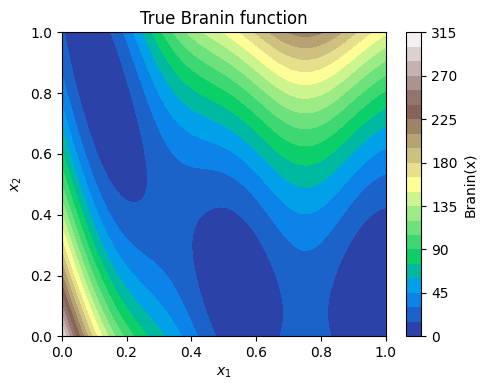

In [6]:
def branin(X):
    X = np.atleast_2d(X)
    x1 = X[:, 0] * 15 - 5
    x2 = X[:, 1] * 15
    return (
        (x2 - 5 / (4 * np.pi**2) * x1**2 + 5 / np.pi * x1 - 6) ** 2
        + 10 * (1 - 1 / (8 * np.pi)) * np.cos(x1)
        + 10
    )

# 50x50 evaluation grid
grid_x = np.linspace(0, 1, 50)
G1, G2  = np.meshgrid(grid_x, grid_x)
grid    = np.column_stack([G1.ravel(), G2.ravel()])
z_true  = branin(grid).reshape(50, 50)

plt.figure(figsize=(5, 4))
plt.contourf(G1, G2, z_true, levels=20, cmap='terrain')
plt.colorbar(label='Branin(x)')
plt.title('True Branin function')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.tight_layout()
plt.show()

## 3. Design of experiments

We discretize $x_1$ into 5 ordered levels (0, 1, 2, 3, 4), each mapped to an
equally spaced center in $[0, 1]$, and sample $n = 40$ points.

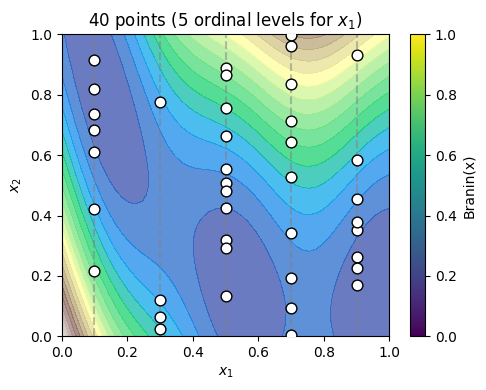

In [7]:
rng = np.random.default_rng(42)

L = 5  # number of ordered levels
n = 40
ord_centers = np.linspace(0.1, 0.9, L)

def lhs(n, d, rng):
    X = np.empty((n, d))
    for j in range(d):
        perm = rng.permutation(n)
        X[:, j] = (perm + rng.uniform(size=n)) / n
    return X

# x1 is ordinal: randomly assign levels
x1_level = rng.integers(0, L, size=n).astype(float)
x2 = lhs(n, 1, rng).ravel()

# Evaluate Branin at the ordinal level's center for x1
X_eval = np.column_stack([ord_centers[x1_level.astype(int)], x2])
y = branin(X_eval)

# For WarpKriging, x1 is passed as integer level (0..L-1)
X = np.column_stack([x1_level, x2])

plt.figure(figsize=(5, 4))
plt.contourf(G1, G2, z_true, levels=20, cmap='terrain', alpha=0.7)
plt.scatter(X_eval[:, 0], X_eval[:, 1], c='white', edgecolors='black', s=60, zorder=5)
for lvl in range(L):
    plt.axvline(ord_centers[lvl], color='grey', linestyle='--', alpha=0.5)
plt.colorbar(label='Branin(x)')
plt.title(f'{n} points ({L} ordinal levels for $x_1$)')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.tight_layout()
plt.show()

## 4. Fit a WarpKriging model (`ordinal`)

We use `ordinal(5)` for $x_1$ (5 ordered levels → learned positions on $\mathbb{R}$)
and `kumaraswamy` for the continuous $x_2$.

In [8]:
wk = lk.WarpKriging(
    y, X,
    warping=['ordinal(5)', 'kumaraswamy'],
    kernel='matern5_2',
    optim='Adam',
    parameters={'max_iter_adam': '500'}
)
print(wk.summary())

* WarpKriging
* data: 40x[0,4],[0.00349381,0.996335] -> 40x[1.40169,209.108]
* trend constant (est.): 2037.34
* variance (est.): 2.04568e+06
* covariance:
  * kernel: matern5_2
  * range (est.): 6.01849, 7.39418
  * warpings:
      x0: "ordinal(5)"  →  Ordinal(L=5, positions=        0   0.9967   1.9951   2.9909   3.9957
)
      x1: "kumaraswamy"  →  Kumaraswamy(a=0.995123, b=0.998471)
  * total warp params: 6
  * fit:
    * objective: LL
    * optim: Adam



## 5. Predict and plot

We predict at each ordinal level over a dense grid for $x_2$.

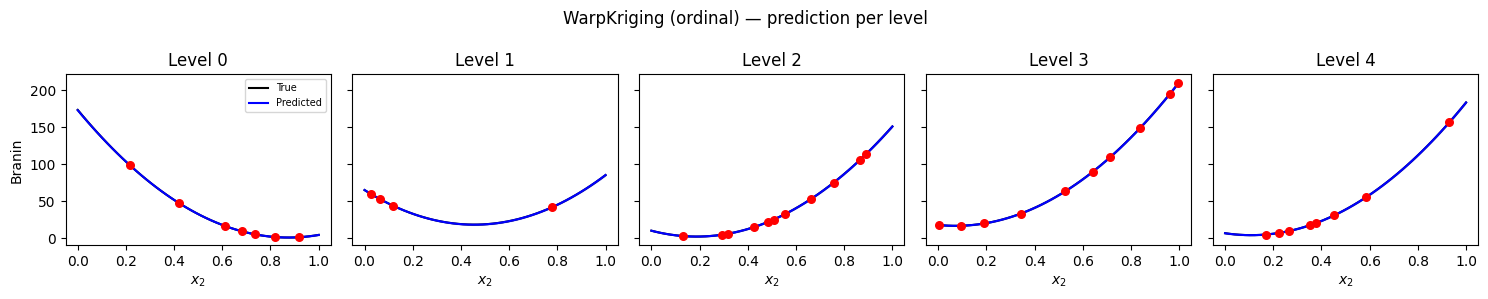

In [9]:
x2_grid = np.linspace(0, 1, 50)

fig, axes = plt.subplots(1, L, figsize=(3 * L, 3), sharey=True)
for lvl in range(L):
    X_pred = np.column_stack([np.full(50, float(lvl)), x2_grid])
    mean, stdev, *_ = wk.predict(X_pred)
    mean = mean.ravel()
    stdev = stdev.ravel()

    # True Branin at this level's center
    X_true = np.column_stack([np.full(50, ord_centers[lvl]), x2_grid])
    y_true = branin(X_true)

    ax = axes[lvl]
    ax.plot(x2_grid, y_true, 'k-', label='True')
    ax.plot(x2_grid, mean, 'b-', label='Predicted')
    ax.fill_between(x2_grid, mean - 2*stdev, mean + 2*stdev, alpha=0.2, color='blue')

    mask = x1_level == lvl
    ax.scatter(x2[mask], y[mask], c='red', s=30, zorder=5)
    ax.set_title(f'Level {lvl}')
    ax.set_xlabel('$x_2$')
    if lvl == 0:
        ax.set_ylabel('Branin')
        ax.legend(fontsize=7)

plt.suptitle('WarpKriging (ordinal) — prediction per level', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Model inspection

Key fitted parameters: length-scales $\theta$, variance $\sigma^2$, log-likelihood, and warping specification.

In [10]:
print(f"Kernel       : {wk.kernel()}")
print(f"Theta (range): {np.round(wk.theta(), 4)}")
print(f"Sigma2       : {wk.sigma2():.4f}")
print(f"LogLikelihood: {wk.logLikelihood():.4f}")
print(f"Feature dim  : {wk.feature_dim()}")
print(f"Warping      : {wk.warping()}")

Kernel       : matern5_2
Theta (range): [[6.0185]
 [7.3942]]
Sigma2       : 2045684.9873
LogLikelihood: -37.0988
Feature dim  : 2
Warping      : ['ordinal(5)', 'kumaraswamy']
